In [ ]:
#SVM notebook 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

In [28]:
df=pd.read_csv("seismic_activity_svm.csv")
df.head(15)
#underground wave energy
#vibration axis variation
#seismic event > 0 =  not a seismic event 1 = seismic event

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0
5,9.629452,-2.696970,0
6,9.646221,-2.636364,0
7,9.662581,-2.575758,0
8,9.678534,-2.515152,0
9,9.694081,-2.454545,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


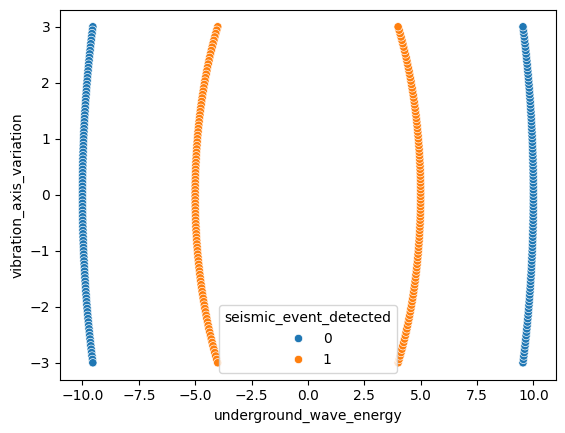

In [30]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

In [31]:
#manuel rbf kernel

df.columns

Index(['underground_wave_energy', 'vibration_axis_variation',
       'seismic_event_detected'],
      dtype='object')

In [32]:
df['underground_wave_energy **2']= df['underground_wave_energy']**2
df['vibration_axis_variation **2']= df['vibration_axis_variation']**2
df['underground_wave_energy*vibration_axis_variation'] = (df['underground_wave_energy'] *df['vibration_axis_variation'])
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy*vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,9.000000,-28.618176
1,9.558241,-2.939394,0,91.359963,8.640037,-28.095434
2,9.576669,-2.878788,0,91.712580,8.287420,-27.569197
3,9.594678,-2.818182,0,92.057851,7.942149,-27.039548
4,9.612272,-2.757576,0,92.395776,7.604224,-26.506569


In [33]:
X=df.drop("seismic_event_detected",axis=1)
y=df["seismic_event_detected"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)

In [34]:
import plotly.express as px

In [35]:
fig = px.scatter_3d(df, x='underground_wave_energy **2', y='vibration_axis_variation **2', z='underground_wave_energy*vibration_axis_variation',
              color='seismic_event_detected')
fig.show()

In [39]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
linear=SVC(kernel='linear')
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[50  0]
 [ 0 50]]


In [40]:
#automatic rbf
df2 = pd.read_csv("seismic_activity_svm.csv")
X2=df2.drop('seismic_event_detected',axis=1)
y2=df2['seismic_event_detected']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.25, random_state = 34)

In [45]:
linear2=SVC(kernel='linear')
linear2.fit(X_train2,y_train2)
y_pred2=linear.predict(X_test)
print(classification_report(y_pred, y_test2))
print(confusion_matrix(y_pred2, y_test2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[50  0]
 [ 0 50]]


In [46]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train2,y_train2)
y_pred3=rbf.predict(X_test2)
print(classification_report(y_test2,y_pred3))
print(confusion_matrix(y_test2,y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[50  0]
 [ 0 50]]
